Running TRACTS multiple-wave model...
Running msprime multiple-wave simulation...
Extracting tracts...

Multiple-wave plots saved!


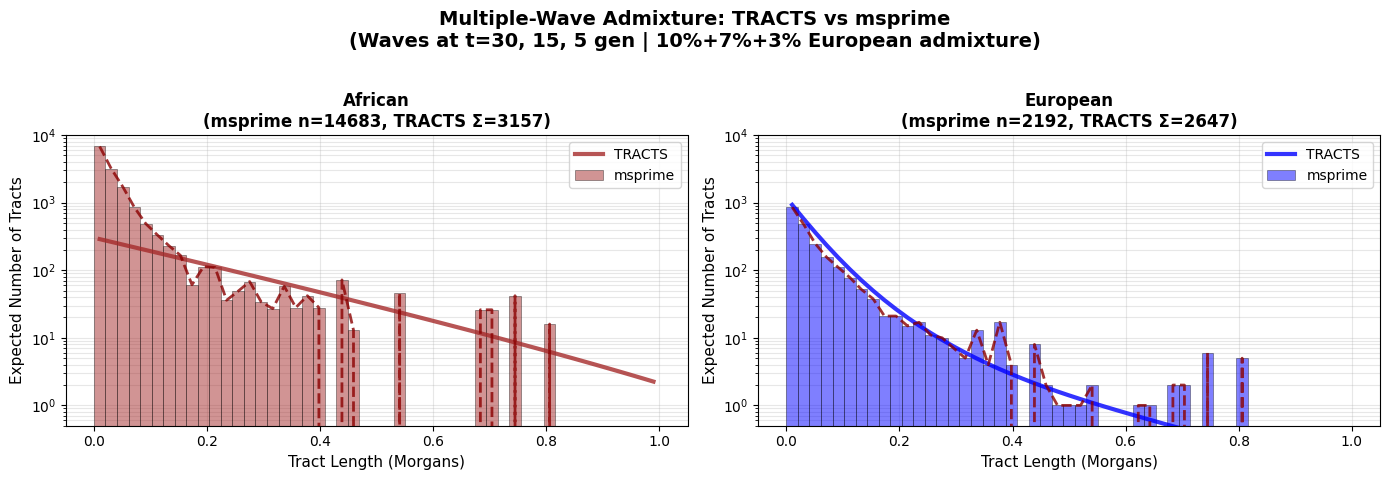


MULTIPLE-WAVE ADMIXTURE SUMMARY
Three admixture waves at t=30, 15, 5 generations
Wave 1 (t=30): 90% African, 10% European (founding)
Wave 2 (t=15): +7% European
Wave 3 (t=5): +3% European
Final expected: ~80% African, ~20% European

African ancestry:
  msprime: n=14683, mean=0.0512 M
  TRACTS: Σ=3157

European ancestry:
  msprime: n=2192, mean=0.0609 M
  TRACTS: Σ=2647


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import msprime
import tskit
from collections import defaultdict

# Try to import tracts
try:
    import tracts
    HAS_TRACTS = True
except ImportError:
    HAS_TRACTS = False
    print("Warning: tracts not available")

# ============================================================================
# SCENARIO 1: MULTIPLE-WAVE ADMIXTURE (CORRECTED)
# Example: African American history with multiple European admixture events
# ============================================================================

# Parameters
t1, t2, t3 = 30, 15, 5  # Three admixture waves (30, 15, 5 generations ago)

sequence_length = 1e8  # 100 Mb = 1 Morgan
r = 1e-8
Ne = 10000
sample_size = 200
bins = np.linspace(0, 1, 50)
Ls = [1.0]

# ============================================================================
# TRACTS: MULTIPLE-WAVE MODEL (CORRECTED)
# ============================================================================
def run_tracts_multiwave():
    """Run TRACTS multiple-wave admixture model"""
    if not HAS_TRACTS:
        return None, None
    
    # TRACTS requires the founding migration (oldest event) to sum to 1.0
    # Create migration matrix
    mig = np.zeros((t1 + 1, 2))  # 2 populations: African (0), European (1)
    
    # FOUNDING EVENT at t1=30 gen: must sum to 1.0
    # Start with 90% African, 10% European
    mig[t1, 0] = 0.90  # African
    mig[t1, 1] = 0.10  # European
    
    # Wave 2 at t2=15 gen: additional 7% European
    mig[t2, 1] = 0.07
    
    # Wave 3 at t3=5 gen: additional 3% European
    mig[t3, 1] = 0.03
    
    model = tracts.DemographicModel(mig)
    
    # Get expected tracts
    y_african = model.expectperbin(Ls, 0, bins)
    y_european = model.expectperbin(Ls, 1, bins)
    
    # Flatten and scale
    y_african = np.array(y_african).flatten()[:len(bins)-1]
    y_european = np.array(y_european).flatten()[:len(bins)-1]
    
    scaling_factor = 2 * sample_size
    y_african_scaled = y_african * scaling_factor
    y_european_scaled = y_european * scaling_factor
    
    return y_african_scaled, y_european_scaled

# ============================================================================
# MSPRIME: MULTIPLE-WAVE MODEL
# ============================================================================
def run_msprime_multiwave(rseed=42):
    """Run msprime multiple-wave admixture simulation"""
    
    demography = msprime.Demography()
    demography.add_population(name="Adm", initial_size=Ne)
    demography.add_population(name="African", initial_size=Ne)
    demography.add_population(name="European", initial_size=Ne)
    
    # Wave 3 (most recent): 3% European at t3=5 gen
    demography.add_mass_migration(time=t3, source="Adm", dest="European", proportion=0.03)
    
    # Wave 2: 7% European at t2=15 gen
    demography.add_mass_migration(time=t2, source="Adm", dest="European", proportion=0.07)
    
    # Wave 1 (oldest/founding): 10% European at t1=30 gen, rest to African
    demography.add_mass_migration(time=t1, source="Adm", dest="European", proportion=0.10)
    demography.add_mass_migration(time=t1, source="Adm", dest="African", proportion=1.0)
    
    print("Running msprime multiple-wave simulation...")
    
    ts = msprime.sim_ancestry(
        samples={"Adm": sample_size},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=r,
        ploidy=2,
        model="dtwf",
        end_time=t1+1,
        record_migrations=True,
        random_seed=rseed
    )
    
    print("Extracting tracts...")
    
    tables = ts.dump_tables()
    migrations = tables.migrations
    num_sample_nodes = 2 * sample_size
    
    z = migrations.node[migrations.node >= num_sample_nodes]
    if z.size > 0:
        linked_edges = ts.tables.link_ancestors(range(num_sample_nodes), np.unique(z))
    else:
        linked_edges = tskit.EdgeTable()
    
    ch_cache = defaultdict(list)
    for edge in linked_edges:
        ch_cache[edge.parent].append(edge)
    
    tracts = [[], [], []]  # 0=Adm, 1=African, 2=European
    for row in migrations:
        if row.node < num_sample_nodes:
            seg_length = row.right - row.left
            tracts[row.dest].append(seg_length)
        else:
            children = ch_cache[row.node]
            for child in children:
                seg_length = child.right - child.left
                tracts[row.dest].append(seg_length)
    
    tracts_morgans = [np.array(t) / sequence_length for t in tracts]
    
    return tracts_morgans[1], tracts_morgans[2]  # African, European

# ============================================================================
# RUN AND PLOT MULTIPLE-WAVE
# ============================================================================

if HAS_TRACTS:
    print("Running TRACTS multiple-wave model...")
    tracts_african, tracts_european = run_tracts_multiwave()
else:
    tracts_african, tracts_european = None, None

msprime_african, msprime_european = run_msprime_multiwave(rseed=42)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pop_labels = ['African', 'European']
colors = ['brown', 'blue']
msprime_data = [msprime_african, msprime_european]
tracts_data = [tracts_african, tracts_european]

for idx, (ax, label, color, msp_tracts, tr_y) in enumerate(
    zip(axes, pop_labels, colors, msprime_data, tracts_data)):
    
    # msprime histogram
    if len(msp_tracts) > 0:
        counts, bin_edges = np.histogram(msp_tracts, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        ax.bar(bin_centers, counts, width=bin_width, 
               alpha=0.5, color=color, edgecolor='black', 
               linewidth=0.5, label='msprime', zorder=2)
        ax.plot(bin_centers, counts, color='darkred', 
                linestyle='--', linewidth=2, alpha=0.8, zorder=4)
    
    # TRACTS
    if HAS_TRACTS and tr_y is not None:
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(bin_centers, tr_y, color=color, linewidth=3, 
                label='TRACTS', alpha=0.8, linestyle='-', zorder=3)
    
    ax.set_yscale('log')
    ax.set_ylim([0.5, 1e4])
    ax.set_xlabel('Tract Length (Morgans)', fontsize=11)
    ax.set_ylabel('Expected Number of Tracts', fontsize=11)
    
    if HAS_TRACTS and tr_y is not None:
        title_str = f'{label}\n(msprime n={len(msp_tracts)}, TRACTS Σ={np.sum(tr_y):.0f})'
    else:
        title_str = f'{label}\n(n={len(msp_tracts)} tracts)'
    ax.set_title(title_str, fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.legend(fontsize=10)

plt.suptitle(f'Multiple-Wave Admixture: TRACTS vs msprime\n' + 
             f'(Waves at t={t1}, {t2}, {t3} gen | 10%+7%+3% European admixture)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("multiwave_admixture_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("multiwave_admixture_comparison.pdf", bbox_inches='tight')
print("\nMultiple-wave plots saved!")
plt.show()

# Statistics
print("\n" + "="*80)
print("MULTIPLE-WAVE ADMIXTURE SUMMARY")
print("="*80)
print(f"Three admixture waves at t={t1}, {t2}, {t3} generations")
print(f"Wave 1 (t={t1}): 90% African, 10% European (founding)")
print(f"Wave 2 (t={t2}): +7% European")
print(f"Wave 3 (t={t3}): +3% European")
print(f"Final expected: ~80% African, ~20% European")

print(f"\nAfrican ancestry:")
print(f"  msprime: n={len(msprime_african)}, mean={np.mean(msprime_african):.4f} M")
if HAS_TRACTS and tracts_african is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_african):.0f}")

print(f"\nEuropean ancestry:")
print(f"  msprime: n={len(msprime_european)}, mean={np.mean(msprime_european):.4f} M")
if HAS_TRACTS and tracts_european is not None:
    print(f"  TRACTS: Σ={np.sum(tracts_european):.0f}")
print("="*80)